In [84]:
# Import required libraries
%reset -f
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.ticker as ticker
import os

In [85]:
# Configuration
file2 = 'S_Pos03_Re100_B0001_T.csv'
folder_name1 = '../Downloaded_data/EXP_DATA/30/sim'  # Simulation folder
folder_name2 = '../Downloaded_data/EXP_DATA/30/exp'  # Experimental folder
#folder_name1 = '../Downloaded_data/Irregular_New_sim_updated_velocity/Irregular_New_sim_updated_velocity/CSV_Files/Sim_csv_files/Irregular_Sim_data_new'  # Simulation folder
#folder_name2 = '../Downloaded_data/Irregular_New_sim_updated_velocity/Irregular_New_sim_updated_velocity/CSV_Files/Exp_csv_files/Experimental_Irregular'  # Experimental folder
n_arrows = 14
# Add constant offsets to velocity components (set to 0 for no offset)
z_velocity_offset = 0.05# Constant term to add to Z-velocity [m/s]    #3 = 0.05;40_1:015, 40_3:0, Ire_1:0.02 ir_3:0.1

In [86]:
# Automatically extract position number from filename
import re
pos_match = re.search(r'Pos(\d+)', file2)
if pos_match:
    pos = int(pos_match.group(1))
    print(f"Automatically detected Position: {pos}")
else:
    pos = 1  # Default fallback
    print(f"Could not detect position from filename, using default: {pos}")


# File paths
file2_path = folder_name2 + '/' + file2 # Experimental filename
file1 = 'SIM_' + file2  # Simulation filename
file1_path = folder_name1 + '/' + file1

# Plot settings

file_type='aver'
#file_type='inst'

axis_1 = 'Points_0'
axis_2 = 'Points_2'

plot_type = 'horizontal'
#plot_type = 'vertical'

label1 = "simulation"
label2 = "experiment"
output_dir = '../Velocity_analysis_30Degree'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

Automatically detected Position: 3


In [87]:
# Define both normalization functions
def normalize_x_axis(df):
    """Normalize Points_0 (x-axis) to range [0,1]"""
    df = df.copy()
    x_min = df['Points_0'].min()
    x_max = df['Points_0'].max()
    df['Points_0_normalized'] = (df['Points_0'] - x_min) / (x_max - x_min)
    return df
def normalize_y_axis(df):
    """Normalize Points_1 (y-axis) to range [0,1]"""
    df = df.copy()
    y_min = df['Points_1'].min()
    y_max = df['Points_1'].max()
    df['Points_1_normalized'] = (df['Points_1'] - y_min) / (y_max - y_min)
    return df
# Create function to do both normalizations in one step
def normalize_xy(df):
    """Normalize both x and y axes to range [0,1]"""
    df = df.copy()
    
    # Normalize x-axis
    x_min = df['Points_0'].min()
    x_max = df['Points_0'].max()
    df['Points_0_normalized'] = (df['Points_0'] - x_min) / (x_max - x_min)
    
    # Normalize y-axis
    y_min = df['Points_1'].min()
    y_max = df['Points_1'].max()
    df['Points_1_normalized'] = (df['Points_1'] - y_min) / (y_max - y_min)
    
    return df

if file_type=='inst':
    var = 'Velocity_2'
    vx = 'Velocity_0'
    vy = 'Velocity_1'
    vz = 'Velocity_2'
else:
    var = 'av_u_2'
    vx = 'av_u_0'
    vy = 'av_u_1'
    vz = 'av_u_2'
    
# Load CSV files
df1 = pd.read_csv(file1_path)  # Simulation data
df2 = pd.read_csv(file2_path)  # Experimental data

df1['av_u_2'] = df1['av_u_2'] + z_velocity_offset
print(f"Loaded {label1}: {df1.shape[0]} points")
print(f"Loaded {label2}: {df2.shape[0]} points")

# Map experimental column names to simulation format
header_mapping = {
    'x': 'Points_0',
    'x ': 'Points_0',
    'y': 'Points_1',
    'y ': 'Points_1',
    'z': 'Points_2',
    'z ': 'Points_2',
    'Vel_u': 'av_u_0',
    'Vel_v': 'av_u_1',
    'Vel_w': 'av_u_2',
    'Vel_mag': 'av_u_Magnitude'
}

df2 = df2.rename(columns=header_mapping)
print("Column mapping complete")
# Define axis columns (both datasets now use same format)
axis_1_df1 = 'Points_0'  # X coordinate
axis_2_df1 = 'Points_2'  # Z coordinate
axis_1_df2 = 'Points_0'
axis_2_df2 = 'Points_2'

# Define velocity columns
vx_df1 = 'av_u_0' 
vz_df1 = 'av_u_2'
vx_df2 = 'av_u_0'
vz_df2 = 'av_u_2' 
var = 'av_u_2'  # Z velocity component for colorbar

# Filter simulation data to match experimental bounds
decimals = 6
axis_1_min = round(df2[axis_1_df2].min(), decimals)
axis_1_max = round(df2[axis_1_df2].max(), decimals)
axis_2_min = round(df2[axis_2_df2].min(), decimals)
axis_2_max = round(df2[axis_2_df2].max(), decimals)

df1 = df1[
    (df1[axis_1_df1].round(decimals) >= axis_1_min) & 
    (df1[axis_1_df1].round(decimals) <= axis_1_max) &
    (df1[axis_2_df1].round(decimals) >= axis_2_min) &
    (df1[axis_2_df1].round(decimals) <= axis_2_max)
]

print(f"Filtered {label1}: {df1.shape[0]} points")

Loaded simulation: 56690 points
Loaded experiment: 128759 points
Column mapping complete
Filtered simulation: 50676 points


In [88]:
# Calculate velocity magnitude
df1_normalized = df1.copy()
df1_normalized["vel_cal"] = np.sqrt(df1_normalized['av_u_0']**2 + df1_normalized['av_u_2']**2)
df2["vel_cal"] = np.sqrt(df2['av_u_0']**2 + df2['av_u_2']**2)

# Create mean velocity comparison table
print("=" * 80)
print("MEAN VELOCITY COMPARISON")
print("=" * 80)

# Create DataFrame for table
velocity_comparison = pd.DataFrame({
    'Component': ['X-velocity (av_u_0)', 'Z-velocity (av_u_2)', 'Total magnitude (vel_cal)'],
    'Experiment [m/s]': [
        df2['av_u_0'].mean(),
        df2['av_u_2'].mean(),
        df2['vel_cal'].mean()
    ],
    'Simulation [m/s]': [
        df1_normalized['av_u_0'].mean(),
        df1_normalized['av_u_2'].mean(),
        df1_normalized['vel_cal'].mean()
    ]
})

# Calculate differences and percentage
velocity_comparison['Difference [m/s]'] = (
    velocity_comparison['Simulation [m/s]'] - velocity_comparison['Experiment [m/s]']
)
velocity_comparison['Relative Diff [%]'] = (
    (velocity_comparison['Difference [m/s]'] / velocity_comparison['Experiment [m/s]']) * 100
)

# Format the numbers
pd.options.display.float_format = '{:.6f}'.format

print("\n" + velocity_comparison.to_string(index=False))
print("\n" + "=" * 80 + "\n")

# Also show maximum velocity comparison for reference
print("=" * 80)
print("MAXIMUM VELOCITY COMPARISON (for reference)")
print("=" * 80)

max_velocity_comparison = pd.DataFrame({
    'Component': ['X-velocity (av_u_0)', 'Z-velocity (av_u_2)', 'Total magnitude (vel_cal)'],
    'Experiment [m/s]': [
        df2['av_u_0'].max(),
        df2['av_u_2'].max(),
        df2['vel_cal'].max()
    ],
    'Simulation [m/s]': [
        df1_normalized['av_u_0'].max(),
        df1_normalized['av_u_2'].max(),
        df1_normalized['vel_cal'].max()
    ]
})

max_velocity_comparison['Difference [m/s]'] = (
    max_velocity_comparison['Simulation [m/s]'] - max_velocity_comparison['Experiment [m/s]']
)
max_velocity_comparison['Relative Diff [%]'] = (
    (max_velocity_comparison['Difference [m/s]'] / max_velocity_comparison['Experiment [m/s]']) * 100
)

print("\n" + max_velocity_comparison.to_string(index=False))
print("\n" + "=" * 80 + "\n")

# Reset display format
pd.reset_option('display.float_format')

MEAN VELOCITY COMPARISON

                Component  Experiment [m/s]  Simulation [m/s]  Difference [m/s]  Relative Diff [%]
      X-velocity (av_u_0)          0.009129          0.006387         -0.002742         -30.031831
      Z-velocity (av_u_2)          0.118092          0.159126          0.041034          34.747625
Total magnitude (vel_cal)          0.140723          0.160577          0.019854          14.108828


MAXIMUM VELOCITY COMPARISON (for reference)

                Component  Experiment [m/s]  Simulation [m/s]  Difference [m/s]  Relative Diff [%]
      X-velocity (av_u_0)          0.077030          0.061247         -0.015783         -20.490047
      Z-velocity (av_u_2)          0.812557          0.768708         -0.043849          -5.396427
Total magnitude (vel_cal)          0.815762          0.771004         -0.044758          -5.486594




In [89]:
# Determine common bounds automatically from experimental data
x_min_exp = df2[axis_1_df2].min()
x_max_exp = df2[axis_1_df2].max()
z_min_exp = df2[axis_2_df2].min()
z_max_exp = df2[axis_2_df2].max()

# Check simulation data coverage
x_min_sim = df1_normalized[axis_1_df1].min()
x_max_sim = df1_normalized[axis_1_df1].max()
z_min_sim = df1_normalized[axis_2_df1].min()
z_max_sim = df1_normalized[axis_2_df1].max()

print("DOMAIN VALIDATION CHECK")
print(f"{label2.upper()} domain:")
print(f"  X: [{x_min_exp:.6f}, {x_max_exp:.6f}] m")
print(f"  Z: [{z_min_exp:.6f}, {z_max_exp:.6f}] m")
print(f"{label1.upper()} domain:")
print(f"  X: [{x_min_sim:.6f}, {x_max_sim:.6f}] m")
print(f"  Z: [{z_min_sim:.6f}, {z_max_sim:.6f}] m")

# Calculate OVERLAPPING region (intersection of both domains)
x_min_common = max(x_min_exp, x_min_sim)
x_max_common = min(x_max_exp, x_max_sim)
z_min_common = max(z_min_exp, z_min_sim)
z_max_common = min(z_max_exp, z_max_sim)

# Use overlapping region as common bounds
common_bounds = (x_min_common, x_max_common, z_min_common, z_max_common)
print("Common overlapping domain:")
print(f"  X: [{common_bounds[0]:.6f}, {common_bounds[1]:.6f}] m")
print(f"  Z: [{common_bounds[2]:.6f}, {common_bounds[3]:.6f}] m")

# Filter both datasets to the common overlapping region
df1_consistent = df1_normalized[
    (df1_normalized[axis_1_df1] >= common_bounds[0]) & 
    (df1_normalized[axis_1_df1] <= common_bounds[1]) &
    (df1_normalized[axis_2_df1] >= common_bounds[2]) &
    (df1_normalized[axis_2_df1] <= common_bounds[3])
].copy()

df2_consistent = df2[
    (df2[axis_1_df2] >= common_bounds[0]) & 
    (df2[axis_1_df2] <= common_bounds[1]) &
    (df2[axis_2_df2] >= common_bounds[2]) &
    (df2[axis_2_df2] <= common_bounds[3])
].copy()

DOMAIN VALIDATION CHECK
EXPERIMENT domain:
  X: [-0.036927, 0.036896] m
  Z: [0.180985, 0.243773] m
SIMULATION domain:
  X: [-0.036750, 0.036750] m
  Z: [0.181150, 0.242625] m
Common overlapping domain:
  X: [-0.036750, 0.036750] m
  Z: [0.181150, 0.242625] m


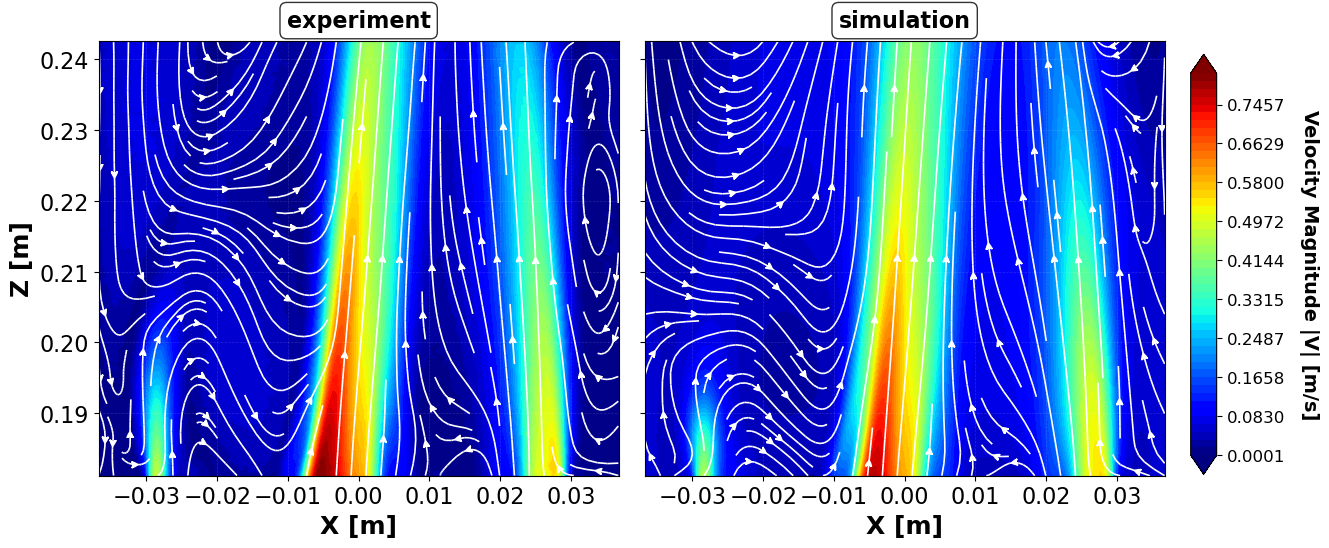

In [90]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# Use consistent data (common overlapping region)
# Calculate color range from velocity magnitude
df1_mag_min = df1_consistent['vel_cal'].min()
df1_mag_max = df1_consistent['vel_cal'].max()
df2_mag_min = df2_consistent['vel_cal'].min()
df2_mag_max = df2_consistent['vel_cal'].max()

# Use combined range for consistent color scale
common_vmin = min(df1_mag_min, df2_mag_min)
common_vmax = max(df1_mag_max, df2_mag_max)

if common_vmax <= common_vmin:
    common_vmax = common_vmin + 0.001

levels = np.linspace(common_vmin, common_vmax, 50)

# Clean data - remove NaN and inf values
df2_clean = df2_consistent.dropna(subset=[axis_1_df2, axis_2_df2, vx_df2, vz_df2, 'vel_cal']).copy()
df1_clean = df1_consistent.dropna(subset=[axis_1_df1, axis_2_df1, vx_df1, vz_df1, 'vel_cal']).copy()
df2_clean = df2_clean[np.isfinite(df2_clean['vel_cal'])]
df1_clean = df1_clean[np.isfinite(df1_clean['vel_cal'])]

# Apply offsets to both datasets
df2_clean[vx_df2] = df2_clean[vx_df2]
df2_clean[vz_df2] = df2_clean[vz_df2]
df1_clean[vx_df1] = df1_clean[vx_df1]
df1_clean[vz_df1] = df1_clean[vz_df1] 

# Recalculate velocity magnitude with offsets
df2_clean['vel_cal'] = np.sqrt(df2_clean[vx_df2]**2 + df2_clean[vz_df2]**2)
df1_clean['vel_cal'] = np.sqrt(df1_clean[vx_df1]**2 + df1_clean[vz_df1]**2)

# Recalculate color range after applying offsets
df1_mag_min = df1_clean['vel_cal'].min()
df1_mag_max = df1_clean['vel_cal'].max()
df2_mag_min = df2_clean['vel_cal'].min()
df2_mag_max = df2_clean['vel_cal'].max()
common_vmin = min(df1_mag_min, df2_mag_min)
common_vmax = max(df1_mag_max, df2_mag_max)
levels = np.linspace(common_vmin, common_vmax, 50)

# Process experimental data for streamlines (X-Z only)
points2 = np.column_stack((df2_clean[axis_1_df2], df2_clean[axis_2_df2]))
x2_points = np.linspace(df2_clean[axis_1_df2].min(), df2_clean[axis_1_df2].max(), n_arrows)
z2_points = np.linspace(df2_clean[axis_2_df2].min(), df2_clean[axis_2_df2].max(), n_arrows)
X2, Z2 = np.meshgrid(x2_points, z2_points)

U2 = griddata(points2, df2_clean[vx_df2].values, (X2, Z2), method='linear', fill_value=0)
V2 = griddata(points2, df2_clean[vz_df2].values, (X2, Z2), method='linear', fill_value=0)

# Normalize streamline directions (for visualization only, not data)
magnitude2 = np.sqrt(U2**2 + V2**2)
mask2 = magnitude2 > 0.0001
U2_norm = np.zeros_like(U2)
V2_norm = np.zeros_like(V2)
U2_norm[mask2] = U2[mask2] / magnitude2[mask2]
V2_norm[mask2] = V2[mask2] / magnitude2[mask2]

# Process simulation data for streamlines (X-Z only)
points1 = np.column_stack((df1_clean[axis_1_df1], df1_clean[axis_2_df1]))
x1_points = np.linspace(df1_clean[axis_1_df1].min(), df1_clean[axis_1_df1].max(), n_arrows)
z1_points = np.linspace(df1_clean[axis_2_df1].min(), df1_clean[axis_2_df1].max(), n_arrows)
X1, Z1 = np.meshgrid(x1_points, z1_points)

U1 = griddata(points1, df1_clean[vx_df1].values, (X1, Z1), method='linear', fill_value=0)
V1 = griddata(points1, df1_clean[vz_df1].values - z_velocity_offset, (X1, Z1), method='linear', fill_value=0)

# Normalize streamline directions (for visualization only, not data)
magnitude1 = np.sqrt(U1**2 + V1**2)
mask1 = magnitude1 > 0.0001
U1_norm = np.zeros_like(U1)
V1_norm = np.zeros_like(V1)
U1_norm[mask1] = U1[mask1] / magnitude1[mask1]
V1_norm[mask1] = V1[mask1] / magnitude1[mask1]

# Create contour plots with velocity magnitude
#1 = EXPERIMENT
#2 = SIMULATION
contour1 = ax1.tricontourf(df2_clean[axis_1_df2].values, df2_clean[axis_2_df2].values, 
                           df2_clean['vel_cal'].values,  # Velocity magnitude
                           levels=levels, cmap='jet', vmin=common_vmin, vmax=common_vmax, extend='both')
ax1.streamplot(X2, Z2, U2_norm, V2_norm, density=1.2, color='white', 
               linewidth=1.2, arrowsize=1.0, arrowstyle='fancy')

contour2 = ax2.tricontourf(df1_clean[axis_1_df1].values, df1_clean[axis_2_df1].values, 
                           df1_clean['vel_cal'].values,  # Velocity magnitude
                           levels=levels, cmap='jet', vmin=common_vmin, vmax=common_vmax, extend='both')
ax2.streamplot(X1, Z1, U1_norm, V1_norm, density=1.2, color='white', 
               linewidth=1.2, arrowsize=1.0, arrowstyle='fancy')

# Configure axes
ax1.set_xlabel('X [m]', fontsize=18, fontweight='bold')
ax1.set_ylabel('Z [m]', fontsize=18, fontweight='bold')
ax2.set_xlabel('X [m]', fontsize=18, fontweight='bold')

# Generate automatic x-axis tick marks
x_tick_spacing = 0.01  # 1 cm spacing
x_ticks = np.arange(np.floor(common_bounds[0]/x_tick_spacing)*x_tick_spacing,
                    np.ceil(common_bounds[1]/x_tick_spacing)*x_tick_spacing + x_tick_spacing/2,
                    x_tick_spacing)
ax1.set_xticks(x_ticks)
ax2.set_xticks(x_ticks)

for ax in [ax1, ax2]:
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.15, color='white', linewidth=0.5)
    ax.tick_params(axis='x', which='both', labelsize=16)
    ax.tick_params(axis='y', which='both', labelsize=16)
    ax.set_xlim(common_bounds[0], common_bounds[1])
    ax.set_ylim(common_bounds[2], common_bounds[3])

ax2.tick_params(axis='y', which='major', labelleft=False)

# Add labels
ax1.text(0.5, 1.02, label2, transform=ax1.transAxes, ha='center', va='bottom',
         fontsize=16, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))
ax2.text(0.5, 1.02, label1, transform=ax2.transAxes, ha='center', va='bottom',
         fontsize=16, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(contour1, cax=cbar_ax)
cbar.set_label('Velocity Magnitude |V| [m/s]', rotation=270, labelpad=25, fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# Adjust layout
plt.subplots_adjust(left=0.08, right=0.90, top=0.90, bottom=0.12, wspace=0.05)

# Save figure
#output_file = f'{output_dir}/100_Pos{pos}_Raw_VelMagnitude_comparison_{file2}.png'
#plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()

In [91]:
# Line plots at specific Z-heights (adaptive based on common domain)
z_min_common = 0.183 #common_bounds[2]
z_max_common = 0.220 #common_bounds[3]       #Hardcoded
z_step = 0.01

z_values = np.arange(z_min_common, z_max_common + 1e-12, z_step)

print(f"Generating line plots from Z = {z_min_common*1000:.3f} mm to {z_max_common*1000:.3f} mm")
print(f"Step size: {z_step*1000:.3f} mm")
print("Z values (mm):", [f"{z*1000:.2f}" for z in z_values])
print(f"Total number of plots: {len(z_values)}")


Generating line plots from Z = 183.000 mm to 220.000 mm
Step size: 10.000 mm
Z values (mm): ['183.00', '193.00', '203.00', '213.00']
Total number of plots: 4


Generating line plots at specified Z values (mm): [183. 193. 203. 213.]
Total number of plots: 4
Target Z = 183.0 mm: simulation Z = 182.950 mm, experiment Z = 183.078 mm
Target Z = 193.0 mm: simulation Z = 192.850 mm, experiment Z = 192.972 mm
Target Z = 203.0 mm: simulation Z = 203.050 mm, experiment Z = 203.056 mm
Target Z = 213.0 mm: simulation Z = 212.950 mm, experiment Z = 212.950 mm
Creating summary subplot with 4 plots (2x2 grid)


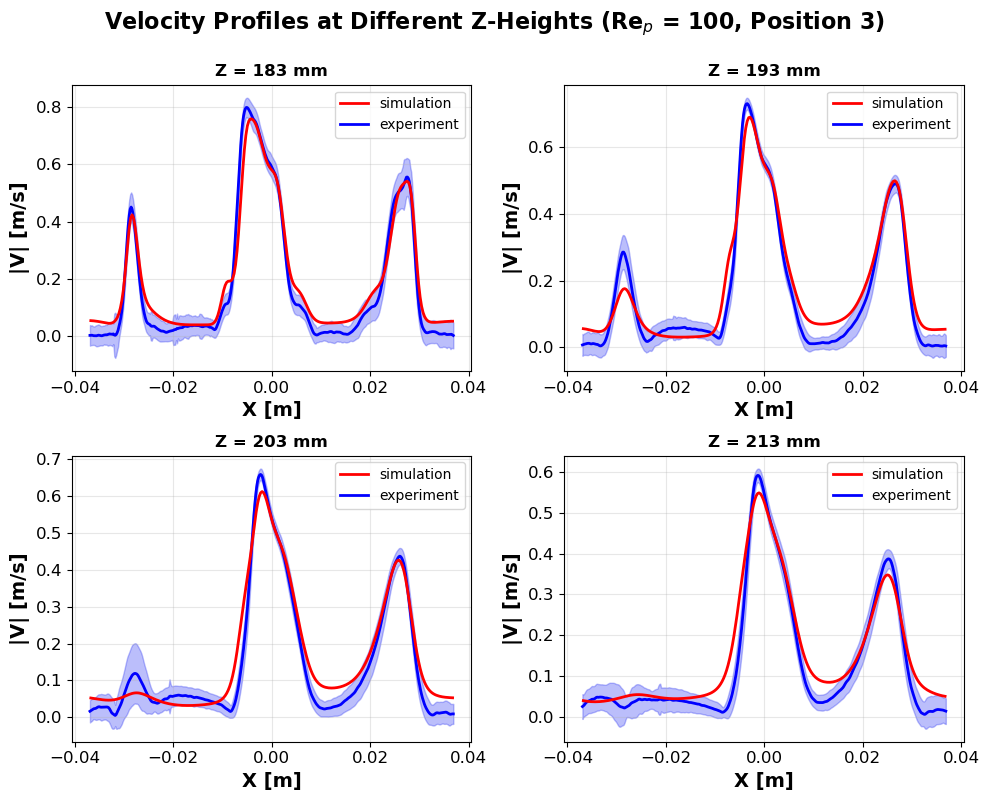

In [92]:
z_values_mm = z_values * 1000  # Convert to mm

# Convert to meters
z_values_m = [z / 1000.0 for z in z_values_mm]

print(f"Generating line plots at specified Z values (mm): {z_values_mm}")
print(f"Total number of plots: {len(z_values_m)}")

z_results = []
z_w_max_sim = []
z_w_max_exp = []
stored_data = []

for z_target in z_values_m:
    deci = 5
    
    # Find closest z-value in each dataset
    closest_y_df1 = df1[axis_2_df1].iloc[(df1[axis_2_df1] - z_target).abs().argsort()[:1]].iloc[0]
    closest_y_df2 = df2[axis_2_df2].iloc[(df2[axis_2_df2] - z_target).abs().argsort()[:1]].iloc[0]
    
    # Print the Z value for each dataset where the plot is being generated
    print(f"Target Z = {z_target*1000:.1f} mm: {label1} Z = {closest_y_df1*1000:.3f} mm, {label2} Z = {closest_y_df2*1000:.3f} mm")
    
    # Filter the data for these closest y values with small tolerance
    df1_filtered = df1[abs(df1[axis_2_df1] - closest_y_df1) < 10**(-deci)]
    df2_filtered = df2[abs(df2[axis_2_df2] - closest_y_df2) < 10**(-deci)]
    
    # Sort the filtered data by the x-axis for proper plotting
    df1_filtered = df1_filtered.sort_values(axis_1_df1)
    df2_filtered = df2_filtered.sort_values(axis_1_df2)
    
    # Calculate velocity magnitude
    magnitude_df1 = np.sqrt(df1_filtered['av_u_0']**2 + df1_filtered['av_u_2']**2)
    magnitude_df2 = np.sqrt(df2_filtered['av_u_0']**2 + df2_filtered['av_u_2']**2)
    
    # Get standard deviations from experimental data
    if 'Stand_dev_Vx' in df2_filtered.columns and 'Stand_dev_Vz' in df2_filtered.columns:
        std_u = df2_filtered['Stand_dev_Vx'].values
        std_w = df2_filtered['Stand_dev_Vz'].values
        
        # Calculate uncertainty in magnitude using error propagation
        u_vals = df2_filtered['av_u_0'].values
        w_vals = df2_filtered['av_u_2'].values
        
        # Avoid division by zero
        magnitude_vals = magnitude_df2.values
        magnitude_vals[magnitude_vals < 1e-10] = 1e-10
        
        std_magnitude = np.sqrt((u_vals * std_u)**2 + (w_vals * std_w)**2) / magnitude_vals
        has_std = True
    else:
        std_magnitude = np.zeros_like(magnitude_df2)
        has_std = False
    
    # Get maximum values
    w_max_sim = magnitude_df1.max() if len(magnitude_df1) > 0 else 0.0
    w_max_exp = magnitude_df2.max() if len(magnitude_df2) > 0 else 0.0
    
    # Store results
    z_results.append(z_target * 1000)
    z_w_max_sim.append(w_max_sim)
    z_w_max_exp.append(w_max_exp)
    
    # Store data for subplot
    stored_data.append({
        'z_target_mm': z_target * 1000,
        'z_sim': closest_y_df1 * 1000,
        'z_exp': closest_y_df2 * 1000,
        'x_sim': df1_filtered[axis_1_df1].values,
        'vel_sim': magnitude_df1.values,
        'x_exp': df2_filtered[axis_1_df2].values,
        'vel_exp': magnitude_df2.values,
        'std_exp': std_magnitude if has_std else None,
        'has_std': has_std
    })
# Create adaptive summary subplot
total_plots = len(stored_data)
if total_plots <= 4:
    n_rows, n_cols = 2, 2
    selected_indices = list(range(total_plots))
elif total_plots <= 9:
    n_rows, n_cols = 3, 3
    selected_indices = list(range(total_plots))
elif total_plots <= 16:
    n_rows, n_cols = 4, 4
    selected_indices = list(range(total_plots))
else:
    n_rows, n_cols = 5, 5
    step = max(1, total_plots // 25)
    selected_indices = list(range(0, total_plots, step))[:25]

# Ensure we have the right number of plots
n_subplots = n_rows * n_cols
selected_indices = selected_indices[:n_subplots]

print(f"Creating summary subplot with {len(selected_indices)} plots ({n_rows}x{n_cols} grid)")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

for i, idx in enumerate(selected_indices):
    data = stored_data[idx]
    ax = axes[i]
    
    # Plot simulation
    ax.plot(data['x_sim'], data['vel_sim'], label=label1, color='r', linestyle='-', linewidth=2, zorder=3)
    
    # Plot experiment with error bars if available
    if data['has_std'] and data['std_exp'] is not None:
        ax.fill_between(data['x_exp'],
                data['vel_exp'] - data['std_exp'],
                data['vel_exp'] + data['std_exp'],
                color="#1e28f2", alpha=0.3, zorder=1)
        ax.plot(data['x_exp'], data['vel_exp'], label=label2,
            color='b', linestyle='-', linewidth=2, zorder=2)
    else:
        ax.plot(data['x_exp'], data['vel_exp'], label=label2, color='b', 
               linestyle='--', linewidth=2, zorder=2)
    
    ax.set_xlabel('X [m]', fontsize=14, fontweight='bold')
    ax.set_ylabel('|V| [m/s]', fontsize=14, fontweight='bold')
    ax.set_title(f'Z = {data["z_target_mm"]:.0f} mm', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=12)

# Hide unused subplots
for i in range(len(selected_indices), len(axes)):
    axes[i].set_visible(False)

plt.suptitle(f'Velocity Profiles at Different Z-Heights (Re$_p$ = 100, Position {pos})', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
#plt.savefig(f'{output_dir}/Summary_Line_Profiles_Pos{pos}.png', dpi=300, bbox_inches='tight')
plt.show()


SUMMARY: Mean and Maximum Velocity Magnitude at Each Z-Slice
 Z_avg_mm   Z_sim_mm  Z_exp_mm  Mean_Vel_Sim_m/s  Mean_Vel_Exp_m/s  Max_Vel_Sim_m/s  Max_Vel_Exp_m/s  Mean_Difference_m/s  Mean_Rel_Diff_%  Max_Difference_m/s  Max_Rel_Diff_%
    183.0 182.950020   183.078          0.197414          0.176321         0.759531         0.799579             0.021094        11.963249           -0.040048       -5.008638
    193.0 192.849994   192.972          0.184149          0.164238         0.689853         0.730624             0.019910        12.122751           -0.040771       -5.580335
    203.0 203.050017   203.056          0.166907          0.147518         0.612370         0.658766             0.019389        13.143642           -0.046397       -7.042962
    213.0 212.949991   212.950          0.156116          0.133883         0.548688         0.591341             0.022233        16.606268           -0.042654       -7.213033

Mean Velocity Statistics:
  Average Difference (Sim - Exp) [m/

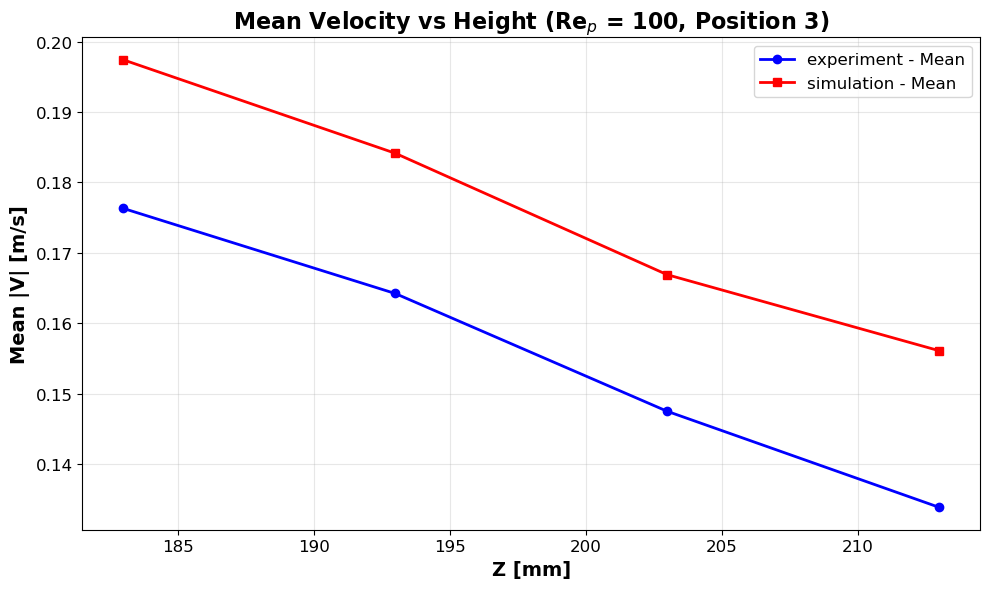

In [93]:
# Calculate mean velocities at each Z-slice for air simulation and experiment
z_mean_vel_sim = []
z_mean_vel_exp = []

for z_target_mm in z_results:
    z_target = z_target_mm / 1000  # Convert to meters
    deci = 5
    
    # Air simulation - compute magnitude directly because df1 may not have 'vel_cal'
    closest_z_sim = df1[axis_2_df1].iloc[(df1[axis_2_df1] - z_target).abs().argsort()[:1]].iloc[0]
    df1_filtered = df1[abs(df1[axis_2_df1] - closest_z_sim) < 10**(-deci)]
    
    if len(df1_filtered) > 0:
        mean_vel_sim = np.sqrt(df1_filtered['av_u_0']**2 + df1_filtered['av_u_2']**2).mean()
    else:
        mean_vel_sim = 0.0
    
    # Experiment
    closest_z_exp = df2[axis_2_df2].iloc[(df2[axis_2_df2] - z_target).abs().argsort()[:1]].iloc[0]
    df2_filtered = df2[abs(df2[axis_2_df2] - closest_z_exp) < 10**(-deci)]
    
    if len(df2_filtered) > 0:
        mean_vel_exp = df2_filtered['vel_cal'].mean()
    else:
        mean_vel_exp = 0.0
    
    z_mean_vel_sim.append(mean_vel_sim)
    z_mean_vel_exp.append(mean_vel_exp)

# Create summary DataFrame - Changed to include MEAN velocity
summary_df = pd.DataFrame({
    'Z_avg_mm': z_results,
    'Z_sim_mm': [data['z_sim'] for data in stored_data],
    'Z_exp_mm': [data['z_exp'] for data in stored_data],
    'Mean_Vel_Sim_m/s': z_mean_vel_sim,
    'Mean_Vel_Exp_m/s': z_mean_vel_exp,
    'Max_Vel_Sim_m/s': z_w_max_sim,
    'Max_Vel_Exp_m/s': z_w_max_exp,
})

# Calculate differences for mean velocities
summary_df['Mean_Difference_m/s'] = summary_df['Mean_Vel_Sim_m/s'] - summary_df['Mean_Vel_Exp_m/s']
summary_df['Mean_Rel_Diff_%'] = (summary_df['Mean_Difference_m/s'] / summary_df['Mean_Vel_Exp_m/s']) * 100

# Calculate differences for max velocities
summary_df['Max_Difference_m/s'] = summary_df['Max_Vel_Sim_m/s'] - summary_df['Max_Vel_Exp_m/s']
summary_df['Max_Rel_Diff_%'] = (summary_df['Max_Difference_m/s'] / summary_df['Max_Vel_Exp_m/s']) * 100

print("\n" + "="*80)
print("SUMMARY: Mean and Maximum Velocity Magnitude at Each Z-Slice")
print("="*80)
print(summary_df.to_string(index=False))

# Average differences across all Z-slices
avg_mean_diff = summary_df['Mean_Difference_m/s'].mean()
avg_abs_mean_diff = summary_df['Mean_Difference_m/s'].abs().mean()
avg_rel_mean_diff = summary_df['Mean_Rel_Diff_%'].mean()

print(f"\nMean Velocity Statistics:")
print(f"  Average Difference (Sim - Exp) [m/s]: {avg_mean_diff:.6f}")
print(f"  Average Absolute Difference [m/s]: {avg_abs_mean_diff:.6f}")
print(f"  Average Relative Difference [%]: {avg_rel_mean_diff:.3f}")

avg_max_diff = summary_df['Max_Difference_m/s'].mean()
avg_abs_max_diff = summary_df['Max_Difference_m/s'].abs().mean()
avg_rel_max_diff = summary_df['Max_Rel_Diff_%'].mean()

print(f"\nMaximum Velocity Statistics:")
print(f"  Average Difference (Sim - Exp) [m/s]: {avg_max_diff:.6f}")
print(f"  Average Absolute Difference [m/s]: {avg_abs_max_diff:.6f}")
print(f"  Average Relative Difference [%]: {avg_rel_max_diff:.3f}")

# Save summary
summary_filename = f'{output_dir}/Velocity_Summary_Pos{pos}.csv'
summary_df.to_csv(summary_filename, index=False)
print(f"\nSummary saved to: {summary_filename}")

# Create plot showing mean velocity variation with height
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(z_results, summary_df['Mean_Vel_Exp_m/s'], 'bo-', label=f'{label2} - Mean', linewidth=2, markersize=6)
ax.plot(z_results, summary_df['Mean_Vel_Sim_m/s'], 'rs-', label=f'{label1} - Mean', linewidth=2, markersize=6)
ax.set_xlabel('Z [mm]', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean |V| [m/s]', fontsize=14, fontweight='bold')
ax.set_title(f'Mean Velocity vs Height (Re$_p$ = 100, Position {pos})', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/Mean_Velocity_vs_Height_Pos{pos}.png', dpi=300, bbox_inches='tight')
plt.show()

# Water Simulation Analysis

In [94]:
# Particle Reynolds number: Re_p = ρ*v_int*d_p/μ
# For the same Re_p and same d_p, we must enforce: ρ_air*v_air/μ_air = ρ_water*v_water/μ_water
# Fluid properties
# Air (20°C): ρ_air = 1.204 kg/m³ ; μ_air = 1.822×10⁻⁵ kg/(m·s)
# Water (20°C): ρ_water = 998 kg/m³ ; μ_water = 1.0×10⁻³ kg/(m·s)

rho_air = 1.204  # kg/m³
mu_air = 1.822e-5  # kg/(m·s)
rho_water = 998  # kg/m³
mu_water = 1.0e-3  # kg/(m·s)

# Calculate the scaling factor for water
v_water_factor = (rho_air * mu_water) / (rho_water * mu_air)

print("="*80)
print("WATER SCALING CALCULATION")
print("="*80)
print(f"\nAir properties (20°C):")
print(f"  Density (ρ_air): {rho_air} kg/m³")
print(f"  Dynamic viscosity (μ_air): {mu_air} kg/(m·s)")
print(f"\nWater properties (20°C):")
print(f"  Density (ρ_water): {rho_water} kg/m³")
print(f"  Dynamic viscosity (μ_water): {mu_water} kg/(m·s)")
print(f"\nScaling Factor (Air → Water): {v_water_factor:.6f}")
print(f"  v_water = v_air × {v_water_factor:.6f}")
print(f"\nThis maintains constant particle Reynolds number (Re_p)")
print(f"Physical basis: ρ_air·v_air/μ_air = ρ_water·v_water/μ_water")
print("="*80)

WATER SCALING CALCULATION

Air properties (20°C):
  Density (ρ_air): 1.204 kg/m³
  Dynamic viscosity (μ_air): 1.822e-05 kg/(m·s)

Water properties (20°C):
  Density (ρ_water): 998 kg/m³
  Dynamic viscosity (μ_water): 0.001 kg/(m·s)

Scaling Factor (Air → Water): 0.066214
  v_water = v_air × 0.066214

This maintains constant particle Reynolds number (Re_p)
Physical basis: ρ_air·v_air/μ_air = ρ_water·v_water/μ_water


In [95]:
# COMPREHENSIVE WATER SIMULATION SUMMARY
print("WATER SIMULATION ANALYSIS (COMPREHENSIVE SUMMARY)")

# Ensure vel_cal exists for df1 (simulation) to avoid KeyError
if 'vel_cal' not in df1.columns:
    df1['vel_cal'] = np.sqrt(df1['av_u_0']**2 + df1['av_u_2']**2)

# Prepare df1_water: if not defined, create a water-scaled copy of df1
if 'df1_water' not in globals():
    df1_water = df1.copy()
    # Ensure velocity columns exist
    for col in ['av_u_0', 'av_u_1', 'av_u_2']:
        if col not in df1_water.columns:
            df1_water[col] = 0.0
    # Apply scaling if v_water_factor is available, otherwise leave unchanged
    if 'v_water_factor' in globals():
        df1_water['av_u_0'] = df1_water['av_u_0'] * v_water_factor
        df1_water['av_u_1'] = df1_water['av_u_1'] * v_water_factor
        df1_water['av_u_2'] = df1_water['av_u_2'] * v_water_factor

# Ensure vel_cal_water exists
if 'vel_cal_water' not in df1_water.columns:
    df1_water['vel_cal_water'] = np.sqrt(df1_water['av_u_0']**2 + df1_water['av_u_2']**2)

# Air simulation statistics
air_mean_u = df1['av_u_0'].mean()
air_mean_w = df1['av_u_2'].mean()
air_mean_mag = df1['vel_cal'].mean()

# Water simulation statistics
water_mean_u = df1_water['av_u_0'].mean()
water_mean_w = df1_water['av_u_2'].mean()
water_mean_mag = df1_water['vel_cal_water'].mean()

# Safe ratio computation (avoid division by zero)
def safe_ratio(a, b):
    return a / b if (b is not None and b != 0) else np.nan

mean_comparison = pd.DataFrame({
    'Component': ['X-velocity (av_u_0)', 'Z-velocity (av_u_2)', 'Velocity Magnitude'],
    'Air_Mean_[m/s]': [air_mean_u, air_mean_w, air_mean_mag],
    'Water_Mean_[m/s]': [water_mean_u, water_mean_w, water_mean_mag],
    'Ratio_Air/Water': [
        safe_ratio(air_mean_u, water_mean_u),
        safe_ratio(air_mean_w, water_mean_w),
        safe_ratio(air_mean_mag, water_mean_mag)
    ]
})

pd.options.display.float_format = '{:.6f}'.format
print("\n" + mean_comparison.to_string(index=False))
if 'v_water_factor' in globals() and v_water_factor != 0:
    print(f"\nExpected Ratio (Air/Water): {1/v_water_factor:.2f}")
else:
    print("\nExpected Ratio (Air/Water): n/a")
print(f"Average Calculated Ratio: {mean_comparison['Ratio_Air/Water'].mean():.2f}")

water_stats = pd.DataFrame({
    'Component': ['u (X-velocity)', 'w (Z-velocity)', '|V| (Magnitude)'],
    'Min [m/s]': [df1_water['av_u_0'].min(), df1_water['av_u_2'].min(), df1_water['vel_cal_water'].min()],
    'Mean [m/s]': [df1_water['av_u_0'].mean(), df1_water['av_u_2'].mean(), df1_water['vel_cal_water'].mean()],
    'Max [m/s]': [df1_water['av_u_0'].max(), df1_water['av_u_2'].max(), df1_water['vel_cal_water'].max()],
    'Std Dev [m/s]': [df1_water['av_u_0'].std(), df1_water['av_u_2'].std(), df1_water['vel_cal_water'].std()]
})

print("\n" + water_stats.to_string(index=False))

# Save water simulation summary
water_summary_path = f'{output_dir}/water_simulation_summary_Pos{pos}.csv'
with open(water_summary_path, 'w') as f:
    f.write(f"# WATER SIMULATION SUMMARY (Position {pos})\n")
    if 'v_water_factor' in globals():
        f.write(f"# Scaling Factor (Air to Water): {v_water_factor:.6f}\n")
    f.write(f"# Air properties: rho={rho_air} kg/m³, mu={mu_air} kg/(m·s)\n")
    f.write(f"# Water properties: rho={rho_water} kg/m³, mu={mu_water} kg/(m·s)\n\n")
    f.write("=== MEAN VELOCITY COMPARISON (AIR vs WATER) ===\n")
    mean_comparison.to_csv(f, index=False)
    f.write("\n=== DETAILED WATER SIMULATION STATISTICS ===\n")
    water_stats.to_csv(f, index=False)

print(f"\n\nSaved water simulation summary to: {water_summary_path}")
z_mean_vel_water = []

for data in stored_data:
    z_target = data['z_target_mm'] / 1000  # Convert back to meters
    deci = 5
    
    # Find closest z-value in water simulation
    closest_y_water = df1_water[axis_2_df1].iloc[(df1_water[axis_2_df1] - z_target).abs().argsort()[:1]].iloc[0]
    
    # Filter the data
    df1_water_filtered = df1_water[abs(df1_water[axis_2_df1] - closest_y_water) < 10**(-deci)]
    
    # Calculate mean velocity magnitude for water
    if len(df1_water_filtered) > 0:
        mean_vel_water = df1_water_filtered['vel_cal_water'].mean()
    else:
        mean_vel_water = 0.0
    
    z_mean_vel_water.append(mean_vel_water)

pd.reset_option('display.float_format')

WATER SIMULATION ANALYSIS (COMPREHENSIVE SUMMARY)

          Component  Air_Mean_[m/s]  Water_Mean_[m/s]  Ratio_Air/Water
X-velocity (av_u_0)        0.006387          0.000423        15.102625
Z-velocity (av_u_2)        0.159126          0.010536        15.102625
 Velocity Magnitude        0.160577          0.010632        15.102625

Expected Ratio (Air/Water): 15.10
Average Calculated Ratio: 15.10

      Component  Min [m/s]  Mean [m/s]  Max [m/s]  Std Dev [m/s]
 u (X-velocity)  -0.002418    0.000423   0.004055       0.001045
 w (Z-velocity)   0.000567    0.010536   0.050899       0.010267
|V| (Magnitude)   0.000639    0.010632   0.051051       0.010230


Saved water simulation summary to: ../Velocity_analysis_30Degree/water_simulation_summary_Pos3.csv


Water simulation velocity range: 0.000639 to 0.051051 m/s

Saved water velocity field to: ../Velocity_analysis_30Degree/Water_Simulation_Velocity_Field_Pos3.png


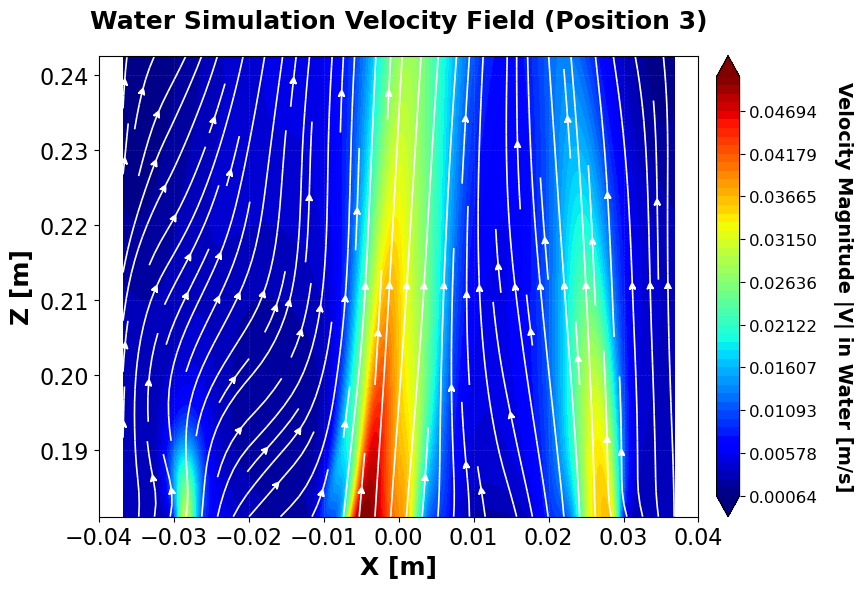

In [98]:
# Filter water simulation to common bounds
df1_water_consistent = df1_water[
    (df1_water[axis_1_df1] >= common_bounds[0]) & 
    (df1_water[axis_1_df1] <= common_bounds[1]) &
    (df1_water[axis_2_df1] >= common_bounds[2]) &
    (df1_water[axis_2_df1] <= common_bounds[3])
].copy()

# Clean data - remove NaN and inf values
df1_water_clean = df1_water_consistent.dropna(subset=[axis_1_df1, axis_2_df1, 'av_u_0', 'av_u_2', 'vel_cal_water']).copy()
df1_water_clean = df1_water_clean[np.isfinite(df1_water_clean['vel_cal_water'])]

# Calculate color range for water simulation
water_vmin = df1_water_clean['vel_cal_water'].min()
water_vmax = df1_water_clean['vel_cal_water'].max()
water_levels = np.linspace(water_vmin, water_vmax, 50)

print(f"Water simulation velocity range: {water_vmin:.6f} to {water_vmax:.6f} m/s")

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Process water simulation data for streamlines
points_water = np.column_stack((df1_water_clean[axis_1_df1], df1_water_clean[axis_2_df1]))
x_points_water = np.linspace(df1_water_clean[axis_1_df1].min(), df1_water_clean[axis_1_df1].max(), n_arrows)
z_points_water = np.linspace(df1_water_clean[axis_2_df1].min(), df1_water_clean[axis_2_df1].max(), n_arrows)
X_water, Z_water = np.meshgrid(x_points_water, z_points_water)

U_water = griddata(points_water, df1_water_clean['av_u_0'].values, (X_water, Z_water), method='linear', fill_value=0)
V_water = griddata(points_water, df1_water_clean['av_u_2'].values, (X_water, Z_water), method='linear', fill_value=0)

# Normalize streamline directions
magnitude_water = np.sqrt(U_water**2 + V_water**2)
mask_water = magnitude_water > 0.0001
U_water_norm = np.zeros_like(U_water)
V_water_norm = np.zeros_like(V_water)
U_water_norm[mask_water] = U_water[mask_water] / magnitude_water[mask_water]
V_water_norm[mask_water] = V_water[mask_water] / magnitude_water[mask_water]

# Create contour plot
contour_water = ax.tricontourf(df1_water_clean[axis_1_df1].values, 
                                df1_water_clean[axis_2_df1].values, 
                                df1_water_clean['vel_cal_water'].values,
                                levels=water_levels, cmap='jet', 
                                vmin=water_vmin, vmax=water_vmax, extend='both')

ax.streamplot(X_water, Z_water, U_water_norm, V_water_norm, 
              density=1.2, color='white', linewidth=1.2, arrowsize=1.0, arrowstyle='fancy')

# Configure axes
ax.set_xlabel('X [m]', fontsize=18, fontweight='bold')
ax.set_ylabel('Z [m]', fontsize=18, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.15, color='white', linewidth=0.5)
ax.tick_params(axis='both', labelsize=16)
ax.set_xlim(common_bounds[0], common_bounds[1])
ax.set_ylim(common_bounds[2], common_bounds[3])

# Generate x-axis tick marks
x_tick_spacing = 0.01  # 1 cm spacing
x_ticks = np.arange(np.floor(common_bounds[0]/x_tick_spacing)*x_tick_spacing,
                    np.ceil(common_bounds[1]/x_tick_spacing)*x_tick_spacing + x_tick_spacing/2,
                    x_tick_spacing)
ax.set_xticks(x_ticks)

# Add colorbar
cbar = fig.colorbar(contour_water, ax=ax, pad=0.02)
cbar.set_label('Velocity Magnitude |V| in Water [m/s]', 
               rotation=270, labelpad=25, fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

plt.title(f'Water Simulation Velocity Field (Position {pos})', 
          fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()

# Save figure
output_file_water = f'{output_dir}/Water_Simulation_Velocity_Field_Pos{pos}.png'
plt.savefig(output_file_water, dpi=300, bbox_inches='tight')
print(f"\nSaved water velocity field to: {output_file_water}")
plt.show()

In [97]:
# Scale simulation velocities to equivalent water velocities
df1_water = df1.copy()

# Scale velocity components
df1_water['av_u_0'] = df1_water['av_u_0'] * v_water_factor
df1_water['av_u_2'] = df1_water['av_u_2'] * v_water_factor

# Recalculate velocity magnitude for water
df1_water['vel_cal_water'] = np.sqrt(df1_water['av_u_0']**2 + df1_water['av_u_2']**2)

print("\nWater Simulation Velocity Statistics:")
print(f"  Min velocity magnitude: {df1_water['vel_cal_water'].min():.6f} m/s")
print(f"  Mean velocity magnitude: {df1_water['vel_cal_water'].mean():.6f} m/s")
print(f"  Max velocity magnitude: {df1_water['vel_cal_water'].max():.6f} m/s")
print(f"  Std Dev: {df1_water['vel_cal_water'].std():.6f} m/s")


Water Simulation Velocity Statistics:
  Min velocity magnitude: 0.000639 m/s
  Mean velocity magnitude: 0.010632 m/s
  Max velocity magnitude: 0.051051 m/s
  Std Dev: 0.010230 m/s
